# OLMo-2-1B × Tulu-3 SFT mixture leaderboard — robustness pilot (9000 steps, ~225M slot-tokens)

Robustness pilot from `~/.claude/plans/as-part-of-our-tender-quilt.md`. Tests whether `adam-polar-product-lora-coupled-spectral-chord-tight` (plain k=1) keeps its eval-loss advantage over AdamW-LoRA when the dataset is swapped from opc-sft-stage2 (code-IFT) to Tulu-3 (general-IFT, chat-templated via the open-instruct Tulu chat template).

Cell: OLMo-2-1B × Tulu-3 SFT mixture (400k subset, ~150k packed slots @ seq=2048) × global_batch=16 (batch=4 × accum=4) × packed_v1.1 × constant LR × α=r × all-linear × bf16 × compile × single-GPU Blackwell. `max_steps=9000`, `eval_every=250`.

- **AdamW**: η ∈ {3e-5, 1e-4, 3e-4}
- **chord-tight k=1** (`adam-polar-product-lora-coupled-spectral-chord-tight`): η ∈ {3e-3, 1e-2, 3e-2}

Source log groups: `{adamw,chord_tight}_robustness_tulu3_1b_r{64,256}_blackwell` (4 groups total).

**σ anchor**: no per-dataset multi-seed AdamW run yet. Quoting Δ against `σ_AdamW(packed_v1, opc-sft-stage2, r=64) = 0.0017` as a **proxy only** — re-anchor before any paper claim.

In [20]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from lora_playground.loader import load_runs
from lora_playground.plotting import compare_variants_figure
from lora_playground.plotting.colors import OPTIM_COLORS, OPTIM_MARKERS

OPT_ADAMW = 'adamw'
OPT_CT    = 'adam-polar-product-lora-coupled-spectral-chord-tight'

def variant_key(cfg):
    opt = cfg.get('optimizer')
    if opt == OPT_ADAMW: return 'AdamW'
    if opt == OPT_CT:    return 'chord-tight k=1'
    return None

VARIANT_COLORS  = {'AdamW': OPTIM_COLORS.get(OPT_ADAMW, 'black'),
                   'chord-tight k=1': OPTIM_COLORS.get(OPT_CT, 'tab:red')}
VARIANT_MARKERS = {'AdamW': OPTIM_MARKERS.get(OPT_ADAMW, 'o'),
                   'chord-tight k=1': OPTIM_MARKERS.get(OPT_CT, 's')}

def render_cell(groups, rank, suptitle):
    runs = load_runs(where={'log_group': groups}, logs_root='../logs',
                     warn_cross_commit=False, quiet=True)
    dedup = {}
    for cfg, hist in runs:
        k = (cfg['optimizer'], float(cfg['lr']))
        if k not in dedup or len(hist) > len(dedup[k][1]):
            dedup[k] = (cfg, hist)
    fig, table_df, summary_df = compare_variants_figure(
        variants={'AdamW': {'optimizer': OPT_ADAMW},
                  'chord-tight k=1': {'optimizer': OPT_CT}},
        common_where={'lora_r': rank}, ref_label='AdamW', sigma_ref=0.0017,
        max_steps=9000, allow_partial=True,
        prefetched_runs=list(dedup.values()), variant_key=variant_key,
        colors=VARIANT_COLORS, markers=VARIANT_MARKERS,
        suptitle=suptitle, figsize=(11, 4),
    )
    plt.show()
    print(f'--- {suptitle} per-η table ---')
    display(table_df.style.format('{:.4f}', na_rep='—'))
    print(f'--- {suptitle} summary ---')
    display(summary_df.style.format({
        'best_lr': '{:.1e}', 'final': '{:.4f}',
        'delta': '{:+.4f}', 'delta_sigma': '{:+.2f}σ'
    }, na_rep='—'))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## r=64

/mnt/home/nghosh/lora/lora_playground/plotting/figures.py:444: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_lr.legend(fontsize=9)
/mnt/home/nghosh/lora/lora_playground/plotting/figures.py:469: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_traj.legend(fontsize=9)


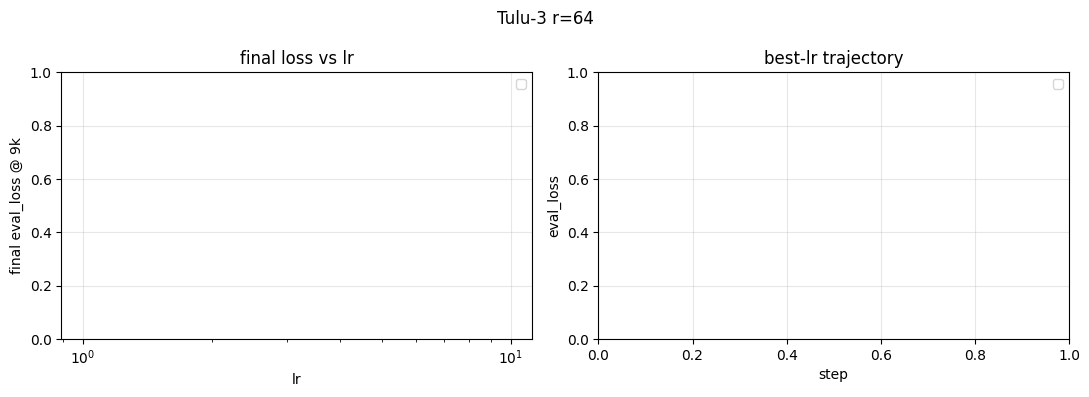

--- Tulu-3 r=64 per-η table ---


,AdamW,chord-tight k=1
lr,,


--- Tulu-3 r=64 summary ---


In [21]:
GROUPS_R64 = [
    'adamw_robustness_tulu3_1b_r64_blackwell',
    'adamw_robustness_tulu3_1b_r64_gpuxl',
    'chord_tight_robustness_tulu3_1b_r64_gpuxl',
]
render_cell(GROUPS_R64, 64, 'Tulu-3 r=64')

## r=256

/mnt/home/nghosh/lora/lora_playground/plotting/figures.py:444: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_lr.legend(fontsize=9)


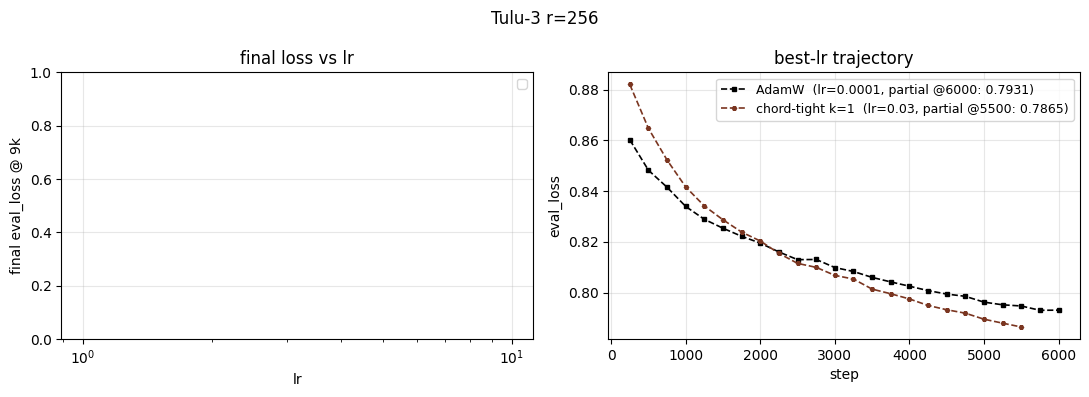

--- Tulu-3 r=256 per-η table ---


,AdamW,chord-tight k=1
lr,,


--- Tulu-3 r=256 summary ---


In [22]:
GROUPS_R256 = [
    'adamw_robustness_tulu3_1b_r256_blackwell',
    'adamw_robustness_tulu3_1b_r256_gpuxl',
    'chord_tight_robustness_tulu3_1b_r256_gpuxl',
]
render_cell(GROUPS_R256, 256, 'Tulu-3 r=256')